In [67]:
import numpy as np
import matplotlib.pyplot as plt

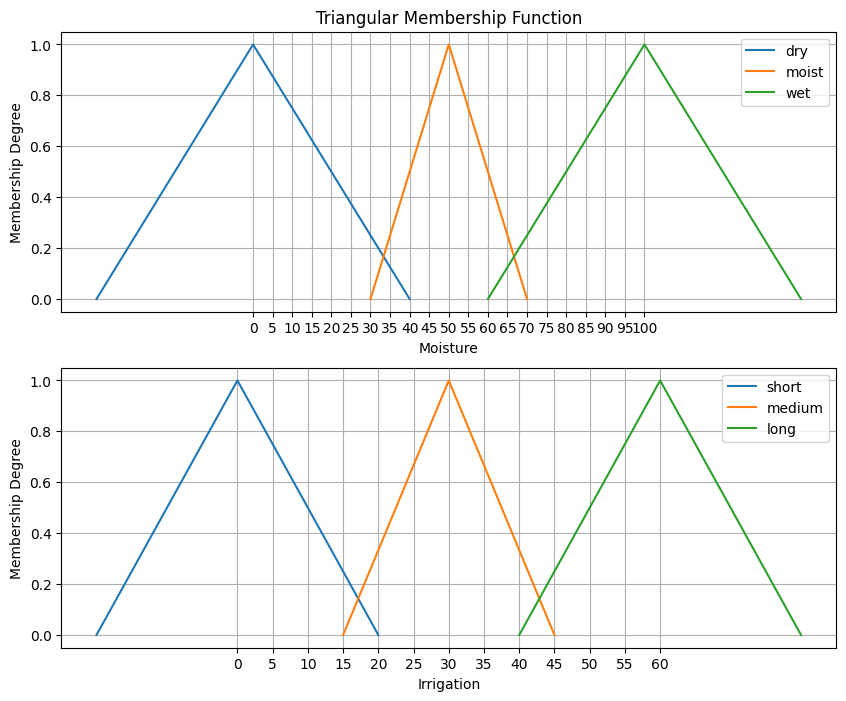

In [68]:
# Input Define:
n=1+1
Moisture={
    'dry':[-40,40],
    'moist':[30,70],
    'wet':[60,140]  
}

# Output Define:
Irrigation={
    'short':[-20,20],
    'medium':[15,45],
    'long':[40,80]
}

y=[0,1,0]
plt.figure(figsize=(10,8))
plt.subplot(n,1,1)
plt.xticks(np.arange(0,105,5))
plt.grid(True)
plt.title('Triangular Membership Function')
plt.xlabel('Moisture')
plt.ylabel('Membership Degree')
for i,j in Moisture.items():
    x=[]
    for k in j:
        x.append(k)
    x.insert(1,np.sum(j)/2)
    plt.plot(x,y,label=i)
    plt.legend()

plt.subplot(n,1,2)
plt.xticks(np.arange(0,65,5))
plt.grid(True)
plt.xlabel('Irrigation')
plt.ylabel('Membership Degree')
for i,j in Irrigation.items():
    x=[]
    yy=[]
    for k in j:
        x.append(k)
    x.insert(1,np.sum(j)/2)
    plt.plot(x,y,label=i)
    plt.legend()
    
plt.show()

In [69]:
def rules(temp):
    if(temp=='dry'):
        return np.sum(Irrigation['long'])/2
    elif(temp=='moist'):
        return np.sum(Irrigation['medium'])/2
    elif(temp=='wet'):
        return np.sum(Irrigation['short'])/2
    
    

In [70]:
def membership_degree(x,s):
    a=Moisture[s][0]
    b=np.mean(Moisture[s])
    c=Moisture[s][1]
    if x>=c:
        return 0
    if x>b:
        return (c-x)/(c-b)
    if x>a:
        return (x-a)/(b-a)
    else:
        return 0

In [71]:
def Fuzzy(x):
    membership_value=[]
    for i in Moisture:
        result=membership_degree(x,i)
        membership_value.append(result)

    print(membership_value)

    crisp_irrigation=[]
    for i in Moisture:
        crisp_irrigation.append(rules(i))
    print(crisp_irrigation)
        
    crisp_irrigation=np.array(crisp_irrigation)
    try:
        crisp_irrigation=crisp_irrigation*np.array(membership_value)
        crisp_irrigation=np.sum(crisp_irrigation)/np.sum(membership_value)
    except:
        crisp_irrigation=0
    
    
    return crisp_irrigation


In [72]:
x=39
print(f"{Fuzzy(x):.3f}")

[np.float64(0.025), np.float64(0.45), 0]
[np.float64(60.0), np.float64(30.0), np.float64(0.0)]
31.579
